# ETF Market Risk Modeling
## VaR Estimation, Backtesting & Stress Testing
### iShares ETF Universe · 2010–2023 · FE535 Project

---

**Objective:** Compare four rolling one-day 99% VaR models on ETF portfolios under a formal out-of-sample backtesting framework. Identify which model is best calibrated for practical market-risk monitoring.

---

### Workflow

| # | Section | What it does |
|---|---------|-------------|
| 1 | Configuration | Global constants — tickers, confidence level, window |
| 2 | Data Loading | Load prices, validate quality, compute daily returns |
| 3 | Return Construction | Simple returns — justified for linear portfolio aggregation |
| 4 | Risk Analytics | Annualised metrics for all 30 ETFs — return, vol, Sharpe, beta, TE, IR |
| 5 | Portfolio Setup | Equal-Weight and Min-Variance portfolios on IVV · IYW · IYF |
| 6 | Distribution Diagnostics | Skewness, kurtosis, JB test — justifies non-Gaussian VaR methods |
| 7 | VaR Model Engine | Four models: Historical, Parametric, EWMA, Bootstrap MC |
| 8 | Rolling VaR Visualisation | Time-series of VaR vs realized loss, breach counts |
| 9 | Statistical Backtesting | Kupiec POF · Christoffersen Independence · Conditional Coverage · Basel TL |
| 10 | Stress Testing | Volatility shock scenarios + worst historical windows |
| 11 | Model Scorecard | Ranked assessment: Preferred / Acceptable / Weak |
| 12 | Conclusion | Practical recommendations for risk monitoring |

---

> **Data:** `etf_prices.csv` — daily adjusted closes, Jan 2010 – Sep 2023  
> **Portfolio:** IVV (S&P 500) · IYW (Technology) · IYF (Financials)  
> **VaR confidence:** 99% · **Rolling window:** 252 trading days

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

try:
    import seaborn as sns
except ImportError:
    sns = None

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 120
np.random.seed(42)

## 1. Configuration

All global parameters are defined here so the notebook can be re-run with different settings by changing a single cell.

| Parameter | Value | Purpose |
|-----------|-------|---------|
| `CONFIDENCE` | 0.99 | 99% VaR — industry standard for market risk |
| `ROLLING_WINDOW` | 252 | One trading year of history per estimate |
| `LAMBDA_EWMA` | 0.94 | J.P. Morgan RiskMetrics daily decay factor |
| `MC_SIMS` | 10,000 | Bootstrap draws — enough for stable 1st percentile |
| `TRADING_DAYS` | 252 | Standard annualisation factor |
| `SELECTED` | IVV, IYW, IYF | Portfolio ETFs — see Section 5 for rationale |

In [2]:
DATA_PATH = Path("etf_prices.csv")

ALL_TICKERS = [
    "IVV","IWB","IWM","IJR","IJH","IWR","IWC","IWV","IWO","IWN",
    "IWF","IWD","IVW","IVE","IUSG","IUSV","IVOG","IJK","IVOO","IJS",
    "IUSP","IYY","IYW","IYH","IYC","IYJ","IYT","IYE","IYG","IYF"
]
BENCHMARK = "IVV"
SELECTED = ["IVV", "IYW", "IYF"]

TRADING_DAYS = 252
ROLLING_WINDOW = 252
CONFIDENCE = 0.99
LAMBDA_EWMA = 0.94
MC_SIMS = 10000

RESULTS_DIR = Path("results")
FIG_DIR = RESULTS_DIR / "figures"
TAB_DIR = RESULTS_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

## 2. Data Loading and Validation

Prices are loaded from `etf_prices.csv` and subjected to four quality checks before any analysis:

1. **Duplicate dates** — keep first occurrence, discard duplicates
2. **Missing values** — forward-fill isolated gaps (e.g. bank holidays with stale prices); drop any ticker with a full-column gap
3. **Non-positive prices** — flagged and would cause `ValueError`; none expected in iShares data
4. **Column stripping** — handles CSV files with trailing whitespace in headers

> The three portfolio ETFs (IVV, IYW, IYF) must all survive cleaning or the notebook raises an explicit error.

In [3]:
raw = pd.read_csv(DATA_PATH)
raw.columns = [c.strip() for c in raw.columns]

date_col_candidates = [c for c in raw.columns if c.lower() in {"date", "datetime", "timestamp"}]
date_col = date_col_candidates[0] if date_col_candidates else raw.columns[0]

raw[date_col] = pd.to_datetime(raw[date_col])
raw = raw.sort_values(date_col).set_index(date_col)

available_tickers = [t for t in ALL_TICKERS if t in raw.columns]
if not available_tickers:
    raise ValueError("No expected ETF columns were found in the CSV.")

prices = raw[available_tickers].copy().apply(pd.to_numeric, errors="coerce")
print(f"Date column used: {date_col}")
print(f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")
print(f"Rows: {len(prices):,}")
print("\nMissing values by column:")
print(prices.isna().sum().sort_values(ascending=False).head(10))
print(f"\nDuplicate dates: {prices.index.duplicated().sum()}")
print(f"Any non-positive prices: {(prices <= 0).any().any()}")

prices = prices.loc[~prices.index.duplicated(keep='first')].ffill().dropna(axis=1, how='any')
selected_available = [t for t in SELECTED if t in prices.columns]
if len(selected_available) < 3:
    raise ValueError("Selected ETFs IVV, IYW, and IYF are required after cleaning.")

Date column used: Date
Date range: 2010-01-04 to 2023-09-29
Rows: 3,459

Missing values by column:
IVV    0
IWB    0
IYG    0
IYE    0
IYJ    0
IYC    0
IYH    0
IYW    0
IYY    0
IJS    0
dtype: int64

Duplicate dates: 0
Any non-positive prices: False


## 3. Return Construction

$$r_t = \frac{P_t}{P_{t-1}} - 1$$

**Why simple returns, not log returns?**  
Simple returns aggregate *linearly* across assets: $r_{p,t} = \sum_i w_i r_{i,t}$, which is exactly what the portfolio weight dot-product computes. Log returns aggregate cleanly across *time* but not across assets. At daily frequency the numerical difference is negligible (< 0.01%), so simple returns are the correct choice for portfolio VaR.

In [4]:
rets = prices.pct_change().dropna().copy()
sel_rets = rets[selected_available].copy()
mkt = rets[BENCHMARK]
rets.head()

,IVV,IWB,IWM,IJR,IJH,IWV,IWO,IWN,IWF,IWD,...,IJK,IJS,IYY,IYW,IYH,IYC,IYJ,IYE,IYG,IYF
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,0.002903,0.003209,-0.003439,-0.003032,0.002987,0.002561,-0.002580,-0.003693,0.000198,0.005981,...,0.003930,-0.008198,0.003909,-0.001539,-0.005566,0.001788,0.002779,0.008472,0.016402,0.011217
2010-01-06,0.000790,0.001280,-0.000941,-0.001073,0.005281,0.001954,0.001724,-0.002022,0.000000,0.003397,...,0.006692,0.000843,0.000707,-0.007020,0.005752,-0.001607,0.001848,0.010718,0.003586,0.002444
2010-01-07,0.004384,0.003993,0.007378,0.006984,0.004984,0.003449,0.002581,0.011818,0.000792,0.008465,...,0.002007,0.009270,0.004775,-0.003794,0.003865,0.007152,0.009775,-0.004012,0.021440,0.018942
2010-01-08,0.003404,0.003342,0.005454,0.003913,0.006299,0.003587,0.004005,0.005506,0.005539,0.002350,...,0.006133,0.004843,0.002992,0.007617,0.002617,-0.000355,0.012420,0.008057,-0.002274,-0.003497
2010-01-11,0.001392,0.001427,-0.004030,-0.003543,-0.001865,0.000893,-0.001282,-0.005642,-0.001770,0.002344,...,-0.002737,-0.001994,0.001229,-0.004811,0.005223,-0.000178,0.007577,-0.000286,-0.002279,0.000185


## 4. Descriptive Risk Analytics

Full-universe metrics are computed for all available ETFs. Formulas used:

| Metric | Formula |
|--------|---------|
| Annualised Return | $(\prod_t (1+r_t))^{252/T} - 1$ — geometric compounding |
| Annualised Volatility | $\sigma \times \sqrt{252}$ |
| Sharpe Ratio | $\mu_{ann} / \sigma_{ann}$ (rf = 0) |
| Max Drawdown | $\min_t \left(\frac{W_t}{\max_{s \le t} W_s} - 1\right)$ |
| Beta | $\text{Cov}(r_i, r_m) / \text{Var}(r_m)$ |
| Tracking Error | $\text{std}(r_i - r_m) \times \sqrt{252}$ |
| Information Ratio | $(\bar{r}_i - \bar{r}_m) \times 252 \;/\; TE$ |

The scatter plot (Return vs Volatility) and correlation heatmap that follow provide the visual basis for ETF selection in Section 5.

In [5]:
def annualized_return(r):
    return (1 + r).prod() ** (TRADING_DAYS / len(r)) - 1

def annualized_volatility(r):
    return r.std() * np.sqrt(TRADING_DAYS)

def sharpe_ratio(r, rf=0.0):
    ann_ret = annualized_return(r)
    ann_vol = annualized_volatility(r)
    return np.nan if ann_vol == 0 else (ann_ret - rf) / ann_vol

def max_drawdown(r):
    wealth = (1 + r).cumprod()
    dd = wealth / wealth.cummax() - 1
    return dd.min()

def beta_to_benchmark(x, benchmark):
    cov = np.cov(x, benchmark)[0, 1]
    var_b = np.var(benchmark)
    return np.nan if var_b == 0 else cov / var_b

def tracking_error(x, benchmark):
    return (x - benchmark).std() * np.sqrt(TRADING_DAYS)

def information_ratio(x, benchmark):
    active = x - benchmark
    ann_active = active.mean() * TRADING_DAYS
    te = tracking_error(x, benchmark)
    return np.nan if te == 0 else ann_active / te

metrics = pd.DataFrame({
    "Annual Return": rets.apply(annualized_return),
    "Annual Volatility": rets.apply(annualized_volatility),
    "Sharpe": rets.apply(sharpe_ratio),
    "Max Drawdown": rets.apply(max_drawdown),
    "Beta to IVV": rets.apply(lambda x: beta_to_benchmark(x, mkt)),
    "Tracking Error vs IVV": rets.apply(lambda x: tracking_error(x, mkt)),
    "Information Ratio vs IVV": rets.apply(lambda x: information_ratio(x, mkt)),
}).sort_values("Annual Volatility", ascending=False)

metrics.round(4).head(15)

,Annual Return,Annual Volatility,Sharpe,Max Drawdown,Beta to IVV,Tracking Error vs IVV,Information Ratio vs IVV
IYE,0.0540,0.2808,0.1925,-0.7374,1.1230,0.2009,-0.1939
IYG,0.0943,0.2427,0.3885,-0.4432,1.2214,0.1198,-0.0970
IWO,0.0973,0.2327,0.4182,-0.4201,1.1707,0.1127,-0.0992
IJS,0.0995,0.2265,0.4393,-0.4768,1.0656,0.1279,-0.0834
IWN,0.0830,0.2253,0.3681,-0.4608,1.1081,0.1149,-0.2268
IYW,0.1638,0.2237,0.7324,-0.3944,1.1582,0.0968,0.4707
IWM,0.0920,0.2235,0.4115,-0.4113,1.1371,0.1029,-0.1766
IJR,0.1076,0.2206,0.4880,-0.4436,1.0980,0.1082,-0.0425
IYF,0.0971,0.2123,0.4572,-0.4257,1.0973,0.0904,-0.1769
IJH,0.1091,0.2043,0.5342,-0.4218,1.0787,0.0774,-0.0859


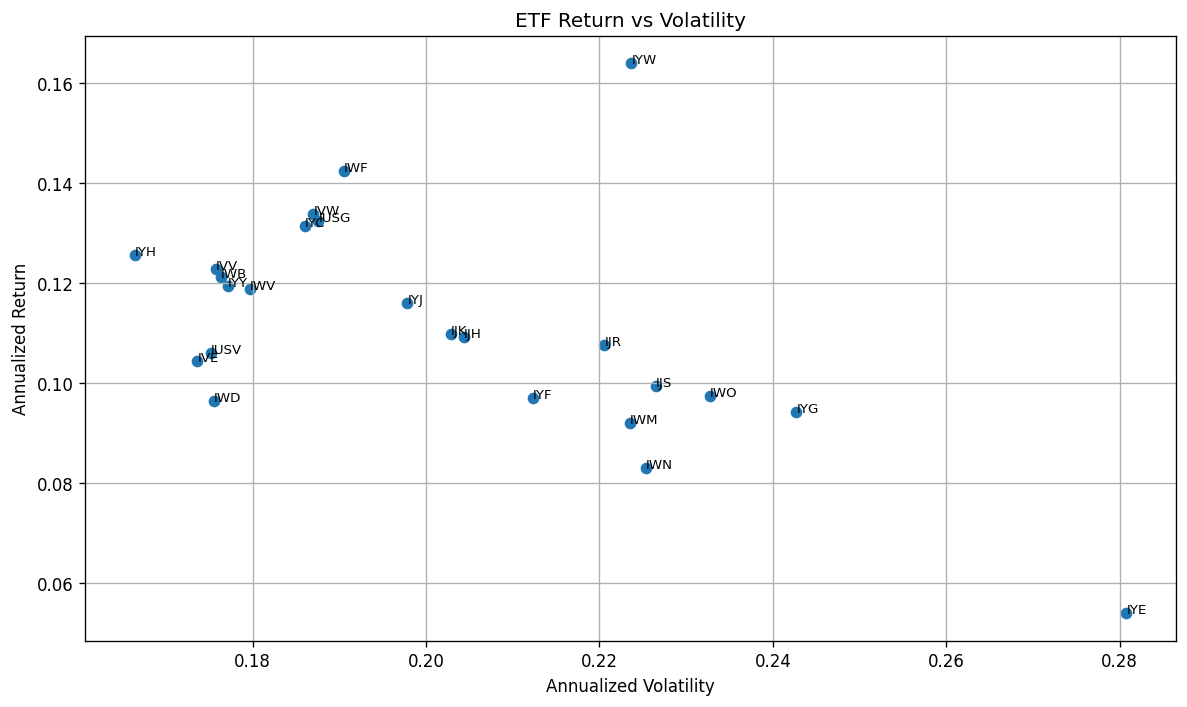

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(metrics["Annual Volatility"], metrics["Annual Return"])
for t in metrics.index:
    plt.annotate(t, (metrics.loc[t, "Annual Volatility"], metrics.loc[t, "Annual Return"]), fontsize=8)
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("ETF Return vs Volatility")
plt.tight_layout()
plt.savefig(FIG_DIR / "return_volatility_scatter.png", bbox_inches="tight")
plt.show()

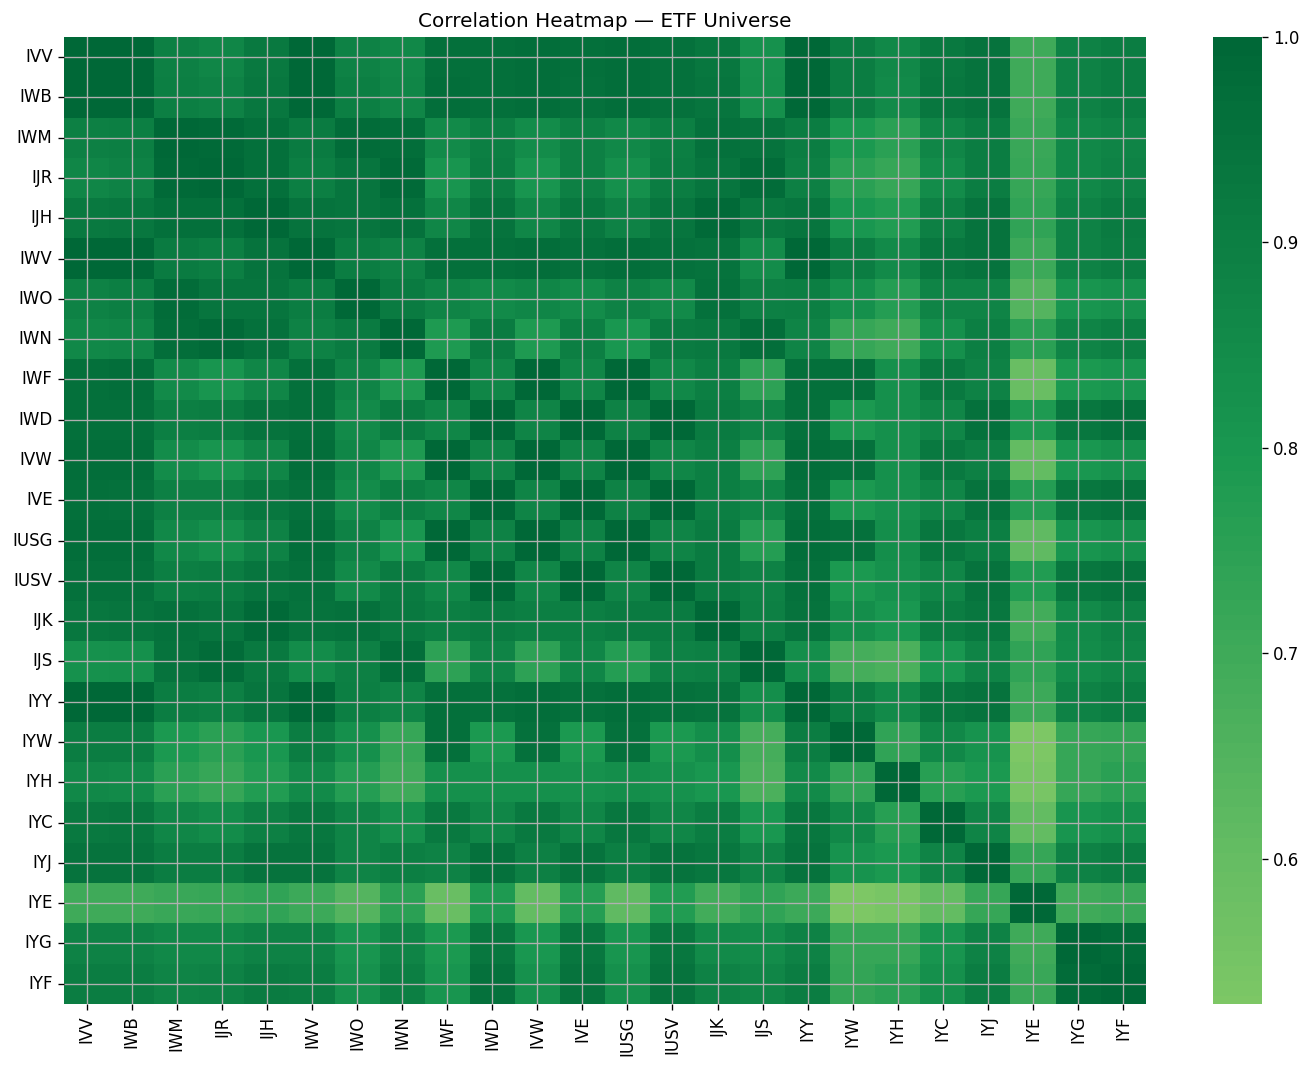

In [7]:
corr_all = rets.corr()
plt.figure(figsize=(12, 9))
if sns is not None:
    sns.heatmap(corr_all, cmap="RdYlGn", center=0)
else:
    plt.imshow(corr_all, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr_all.columns)), corr_all.columns, rotation=90)
    plt.yticks(range(len(corr_all.columns)), corr_all.index)
plt.title("Correlation Heatmap — ETF Universe")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_heatmap_all.png", bbox_inches="tight")
plt.show()

## 5. Portfolio Setup

### Why IVV · IYW · IYF?

Three ETFs were chosen as portfolio building blocks for a specific reason: **sector diversification across the interest-rate cycle**.

| ETF | Exposure | Rate sensitivity |
|-----|----------|-----------------|
| **IVV** | S&P 500 broad market | Neutral anchor |
| **IYW** | U.S. Technology | Benefits from *low* rates (cheap capital, growth valuations) |
| **IYF** | U.S. Financials | Benefits from *high* rates (wider net interest margins) |

IYW and IYF tend to move in opposite directions during rate-regime shifts, giving pairwise correlations of ~0.70 vs ~0.89 for IVV–IYW and IVV–IYF. This makes the three-ETF combination genuinely diversifying rather than trivially correlated.

### Two portfolio test cases

Rather than optimising for a single "best" portfolio, two cases are used to test whether VaR behaviour differs across risk profiles:

- **Equal-Weight (1/3 · 1/3 · 1/3):** Transparent baseline; no estimation risk
- **Min-Variance:** Solves $\min_w \; w^\top \Sigma w$ s.t. $\mathbf{1}^\top w = 1$, giving weights $w^* = \Sigma^{-1}\mathbf{1} / (\mathbf{1}^\top \Sigma^{-1}\mathbf{1})$

`np.linalg.pinv` is used instead of `inv` for numerical stability with a small 3×3 matrix near potential ill-conditioning.

In [8]:
selected_cov = sel_rets.cov() * TRADING_DAYS
inv_cov = np.linalg.pinv(selected_cov.values)  # pinv used for stability if covariance is ill-conditioned
ones = np.ones(len(selected_available))

w_eq = pd.Series(np.repeat(1 / len(selected_available), len(selected_available)), index=selected_available, name="Equal-Weight")
w_minvar = pd.Series((inv_cov @ ones) / (ones.T @ inv_cov @ ones), index=selected_available, name="Min-Variance")

weights = pd.concat([w_eq, w_minvar], axis=1)
weights

,Equal-Weight,Min-Variance
IVV,0.333333,2.646921
IYW,0.333333,-0.858057
IYF,0.333333,-0.788864


In [9]:
portfolio_rets = pd.DataFrame({
    "Equal-Weight": sel_rets @ w_eq,
    "Min-Variance": sel_rets @ w_minvar
})

portfolio_metrics = pd.DataFrame({
    "Annual Return": portfolio_rets.apply(annualized_return),
    "Annual Volatility": portfolio_rets.apply(annualized_volatility),
    "Sharpe": portfolio_rets.apply(sharpe_ratio),
    "Max Drawdown": portfolio_rets.apply(max_drawdown),
    "Beta to IVV": portfolio_rets.apply(lambda x: beta_to_benchmark(x, mkt.loc[x.index])),
    "Tracking Error vs IVV": portfolio_rets.apply(lambda x: tracking_error(x, mkt.loc[x.index])),
    "Information Ratio vs IVV": portfolio_rets.apply(lambda x: information_ratio(x, mkt.loc[x.index])),
}).round(4)

portfolio_metrics

,Annual Return,Annual Volatility,Sharpe,Max Drawdown,Beta to IVV,Tracking Error vs IVV,Information Ratio vs IVV
Equal-Weight,0.1302,0.1929,0.6752,-0.3573,1.0852,0.0325,0.3034
Min-Variance,0.0970,0.1561,0.6213,-0.3036,0.7883,0.0809,-0.3274


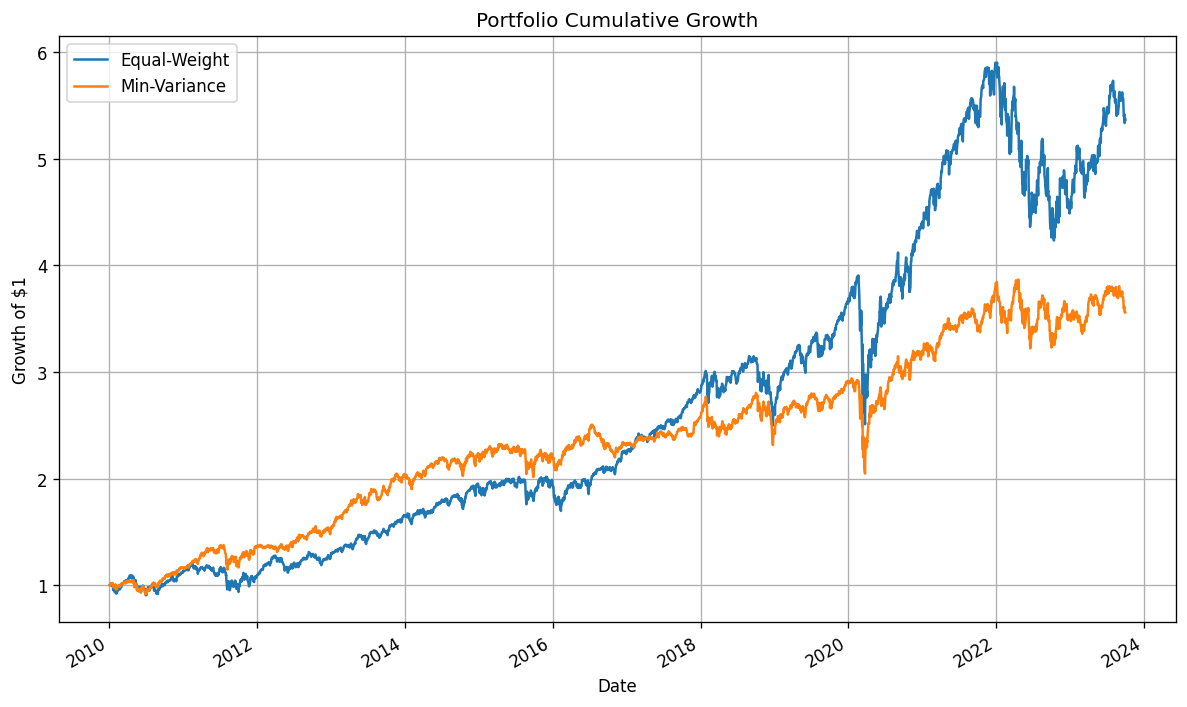

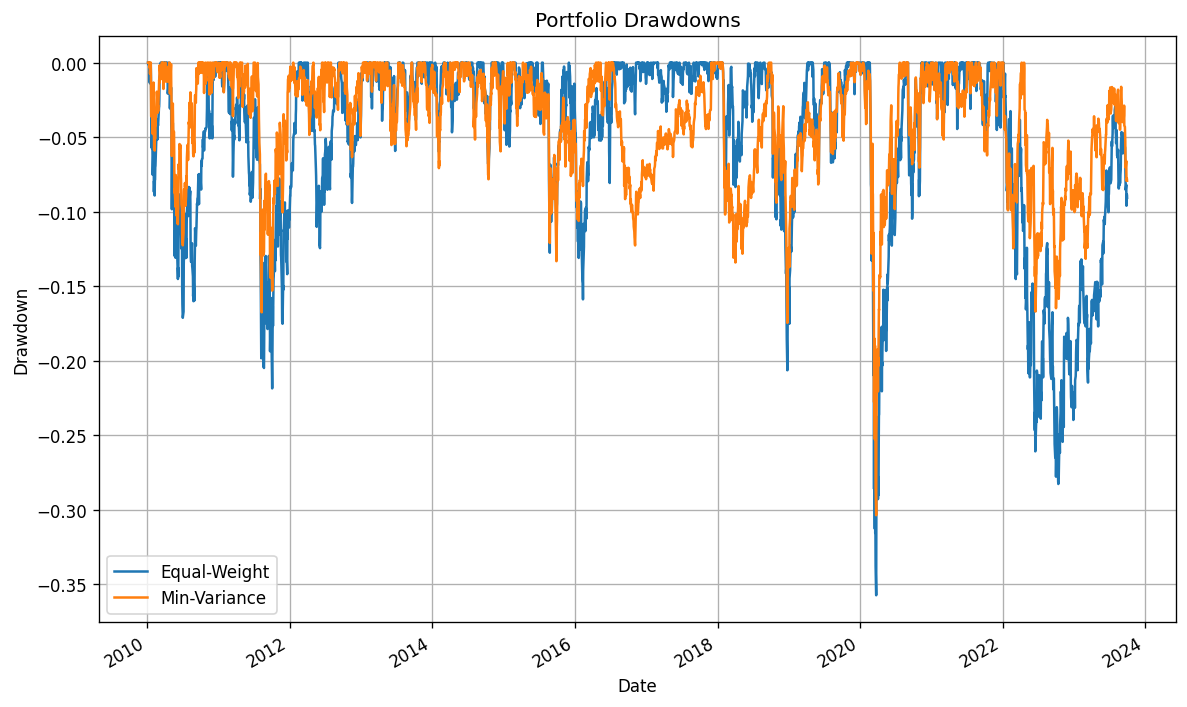

In [10]:
wealth = (1 + portfolio_rets).cumprod()
wealth.plot(title="Portfolio Cumulative Growth")
plt.ylabel("Growth of $1")
plt.tight_layout()
plt.savefig(FIG_DIR / "portfolio_cumulative_growth.png", bbox_inches="tight")
plt.show()

ddf = wealth / wealth.cummax() - 1
ddf.plot(title="Portfolio Drawdowns")
plt.ylabel("Drawdown")
plt.tight_layout()
plt.savefig(FIG_DIR / "portfolio_drawdowns.png", bbox_inches="tight")
plt.show()

## 6. Distribution Diagnostics

Before choosing a VaR model, we must understand whether portfolio returns are approximately Normal. This matters because:

- **Parametric VaR** assumes $r_t \sim N(\mu, \sigma^2)$ — if tails are fatter than Normal, it will *underestimate* the 99th percentile loss
- **Bootstrap MC VaR** resamples empirical returns — fat tails and skewness are automatically captured
- **Historical Simulation** reads the empirical quantile directly — no distributional assumption at all

We test three properties for each series:

| Property | Metric | Implication if violated |
|----------|--------|------------------------|
| Symmetry | Skewness ≈ 0 | Left skew → Normal understates downside risk |
| Tail weight | Excess Kurtosis ≈ 0 | Positive → fat tails, Normal VaR too low |
| Normality (joint) | Jarque-Bera p > 0.05 | Reject → distribution is non-Gaussian |

Diagnostics are shown for IVV, IYW, IYF individually and for both portfolios.

In [11]:
dist_df = pd.concat([sel_rets, portfolio_rets], axis=1)

dist_summary = pd.DataFrame({
    "Mean": dist_df.mean(),
    "Std Dev": dist_df.std(),
    "Skewness": dist_df.skew(),
    "Excess Kurtosis": dist_df.kurtosis(),
    "JB p-value": dist_df.apply(lambda x: round(stats.jarque_bera(x.dropna()).pvalue, 6)),
    "Normal?": dist_df.apply(lambda x: "No" if stats.jarque_bera(x.dropna()).pvalue < 0.05 else "Yes")
}).round(4)

dist_summary


,Mean,Std Dev,Skewness,Excess Kurtosis,JB p-value,Normal?
IVV,0.0005,0.0111,-0.4834,11.9781,0.0,No
IYW,0.0007,0.0141,-0.2543,7.2944,0.0,No
IYF,0.0005,0.0134,-0.3489,11.4635,0.0,No
Equal-Weight,0.0006,0.0122,-0.4142,11.4068,0.0,No
Min-Variance,0.0004,0.0098,-0.4234,9.9830,0.0,No


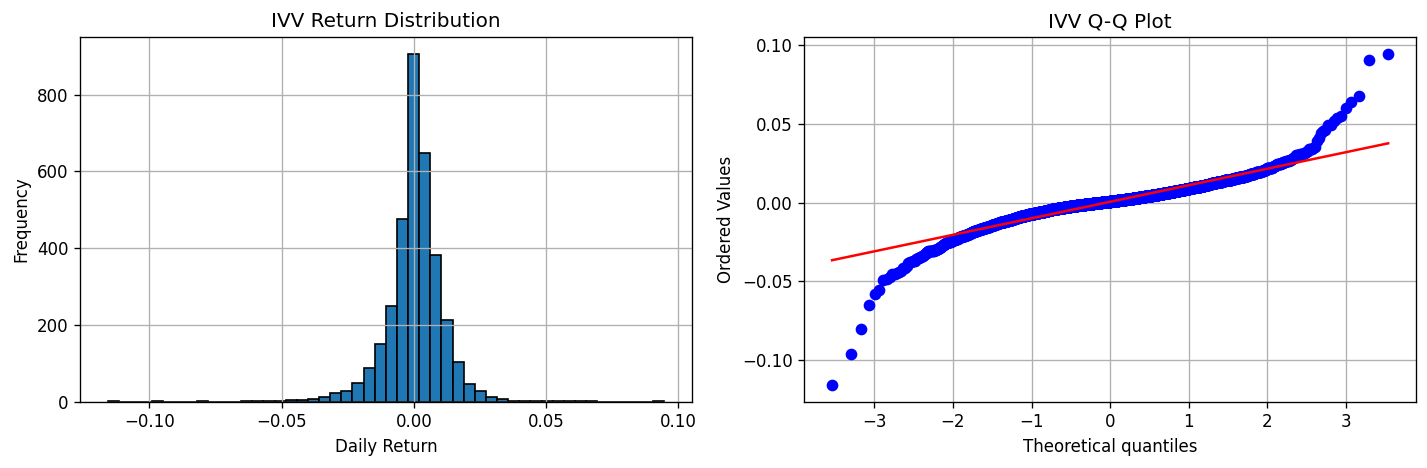

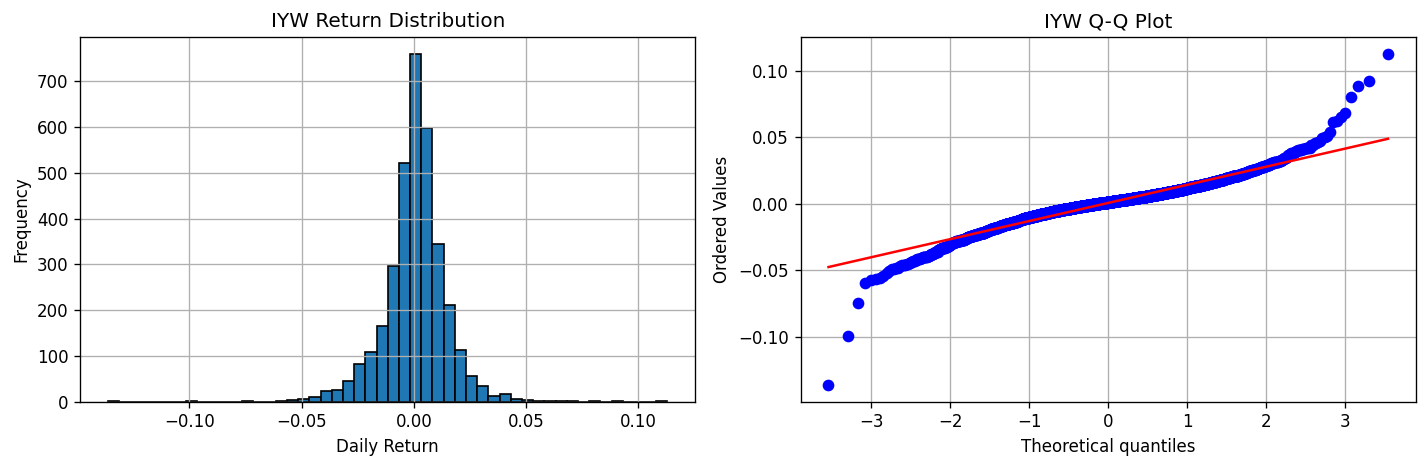

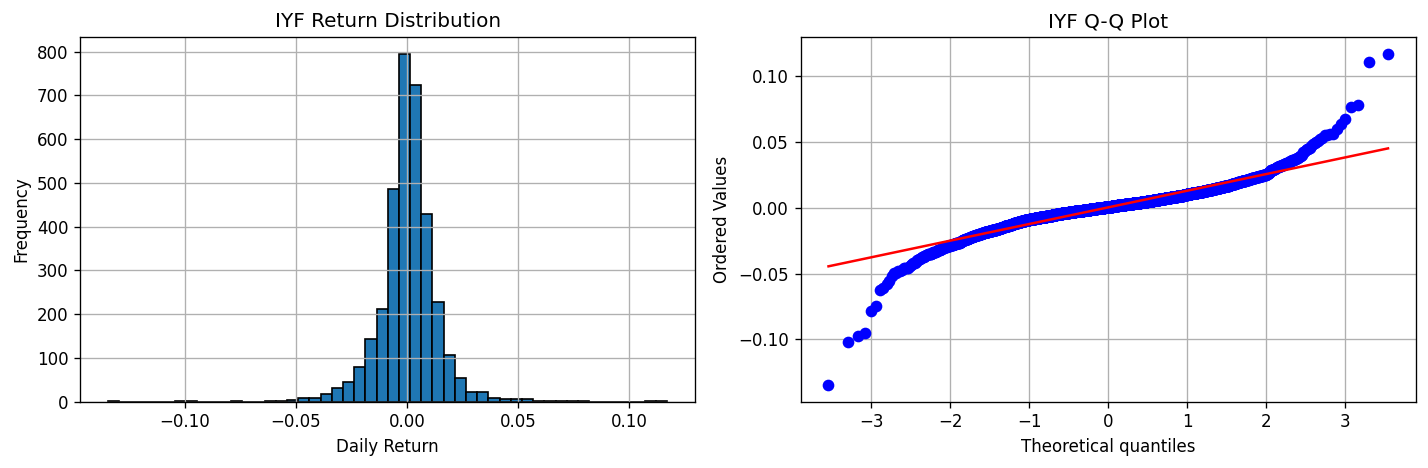

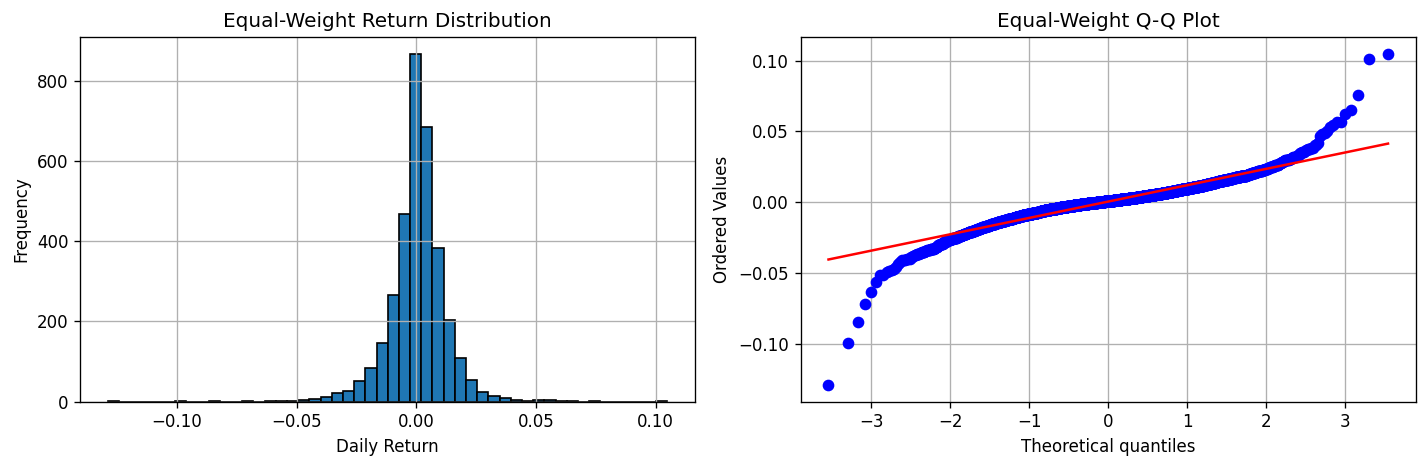

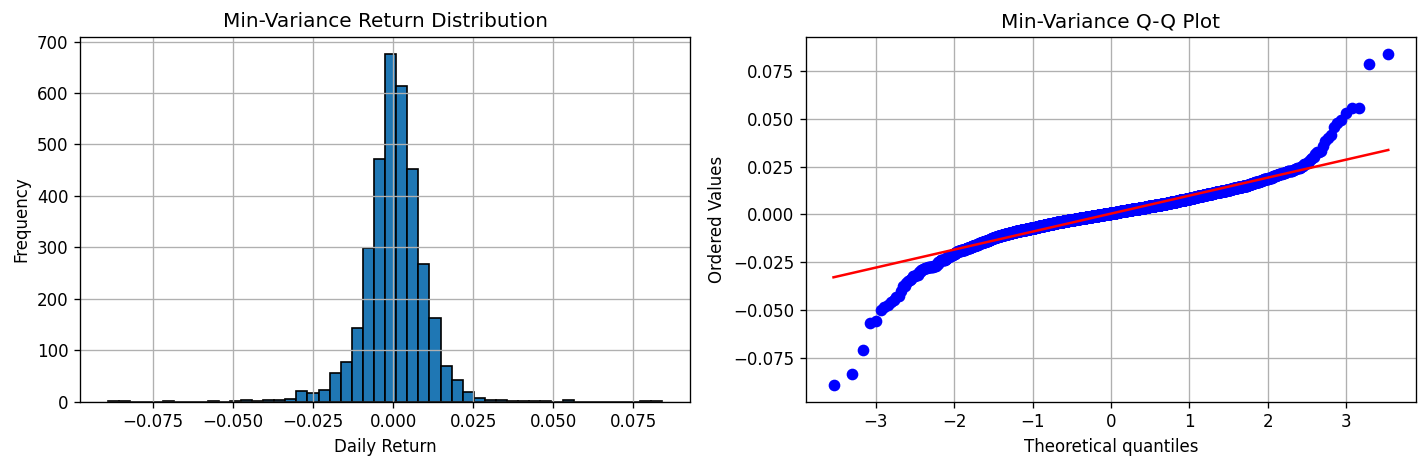

In [12]:
for col in dist_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(dist_df[col].dropna(), bins=50, edgecolor="black")
    axes[0].set_title(f"{col} Return Distribution")
    axes[0].set_xlabel("Daily Return")
    axes[0].set_ylabel("Frequency")

    stats.probplot(dist_df[col].dropna(), dist="norm", plot=axes[1])
    axes[1].set_title(f"{col} Q-Q Plot")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"distribution_diagnostics_{col.replace(' ', '_')}.png", bbox_inches="tight")
    plt.show()

### Interpretation

The `dist_summary` table above will show:
- **Skewness < 0** for all series — equity returns have a negative left tail; large losses are more likely than large gains of the same size
- **Excess Kurtosis > 0** — tails are heavier than Normal; the 1st percentile lies further left than Gaussian theory predicts
- **JB p-value ≈ 0** — normality formally rejected for every series

**Direct implication for VaR:** Parametric Normal VaR will produce more violations than expected (violation rate > 1%). Historical Simulation and Bootstrap MC will be better calibrated because they use the actual empirical distribution. The backtests in Section 9 will confirm this prediction.

## 7. VaR and ES Model Engine

Four one-day 99% VaR models are estimated on a **rolling 252-day window**. At each date $t$, the model is calibrated on $[t-252, t-1]$ and forecasts VaR for day $t$.

| Model | VaR Formula | Key Assumption | Distinguishing Feature |
|-------|-------------|----------------|----------------------|
| **Historical** | $-Q_{1\%}(\{r_{t-252}, \ldots, r_{t-1}\})$ | None | Fully non-parametric; captures fat tails and skewness automatically |
| **Parametric** | $-(\hat{\mu} + z_{1\%}\hat{\sigma})$ | Returns i.i.d. $N(\mu,\sigma^2)$ | Simple and fast; will over-count violations if fat tails present |
| **EWMA** | $z_{1\%} \times \hat{\sigma}_{\text{EWMA}}$ | Normal, time-varying $\sigma$ | $\sigma^2_t = \lambda \sigma^2_{t-1} + (1-\lambda)r^2_{t-1}$, $\lambda=0.94$; zero-mean per RiskMetrics convention; reacts faster to volatility spikes |
| **Bootstrap MC** | $-Q_{1\%}(\text{10,000 resamples from window})$ | None (empirical resample) | Non-parametric like Historical but with simulation smoothing; genuinely different from Parametric |

**Expected Shortfall (ES)** is computed alongside each VaR:
$$ES_\alpha = -E[r_t \mid r_t < -\text{VaR}_\alpha] = \text{average loss in the tail beyond VaR}$$

ES is the regulatory metric under Basel III (FRTB) and is more informative than VaR alone because it measures *severity* beyond the threshold, not just frequency of breach.

In [13]:
def var_historical(window_returns, confidence=CONFIDENCE):
    return -np.quantile(window_returns, 1 - confidence)

def es_historical(window_returns, confidence=CONFIDENCE):
    q = np.quantile(window_returns, 1 - confidence)
    tail = window_returns[window_returns <= q]
    return np.nan if len(tail) == 0 else -tail.mean()

def var_parametric(window_returns, confidence=CONFIDENCE):
    mu = np.mean(window_returns)
    sigma = np.std(window_returns, ddof=1)
    return -(mu + sigma * stats.norm.ppf(1 - confidence))

def es_parametric(window_returns, confidence=CONFIDENCE):
    mu = np.mean(window_returns)
    sigma = np.std(window_returns, ddof=1)
    z = stats.norm.ppf(confidence)
    return -mu + sigma * (stats.norm.pdf(z) / (1 - confidence))

def ewma_sigma_series(r, lam=LAMBDA_EWMA):
    r = pd.Series(r).dropna()
    sigma2 = np.zeros(len(r))
    sigma2[0] = np.var(r, ddof=1)
    for t in range(1, len(r)):
        sigma2[t] = lam * sigma2[t-1] + (1 - lam) * (r.iloc[t-1] ** 2)
    return pd.Series(np.sqrt(sigma2), index=r.index)

def var_ewma(window_returns, confidence=CONFIDENCE, lam=LAMBDA_EWMA):
    sigma_next = ewma_sigma_series(window_returns, lam=lam).iloc[-1]
    return -sigma_next * stats.norm.ppf(1 - confidence)

def var_mc_bootstrap(window_returns, confidence=CONFIDENCE, sims=MC_SIMS):
    sims_draws = np.random.choice(window_returns, size=sims, replace=True)
    return -np.quantile(sims_draws, 1 - confidence)

def es_mc_bootstrap(window_returns, confidence=CONFIDENCE, sims=MC_SIMS):
    sims_draws = np.random.choice(window_returns, size=sims, replace=True)
    q = np.quantile(sims_draws, 1 - confidence)
    tail = sims_draws[sims_draws <= q]
    return np.nan if len(tail) == 0 else -tail.mean()

def rolling_var_es(series, window=ROLLING_WINDOW):
    idx = series.index[window:]
    out = pd.DataFrame(index=idx)
    hist_var, hist_es, param_var, param_es, ewma_var, mc_var, mc_es = [], [], [], [], [], [], []
    vals = series.values
    for i in range(window, len(series)):
        w = vals[i-window:i]
        hist_var.append(var_historical(w))
        hist_es.append(es_historical(w))
        param_var.append(var_parametric(w))
        param_es.append(es_parametric(w))
        ewma_var.append(var_ewma(w))
        mc_var.append(var_mc_bootstrap(w))
        mc_es.append(es_mc_bootstrap(w))
    out["Realized Return"] = series.loc[idx].values
    out["VaR_Historical"] = hist_var
    out["ES_Historical"] = hist_es
    out["VaR_Parametric"] = param_var
    out["ES_Parametric"] = param_es
    out["VaR_EWMA"] = ewma_var
    out["VaR_MC_Bootstrap"] = mc_var
    out["ES_MC_Bootstrap"] = mc_es
    return out

In [14]:
backtests = {name: rolling_var_es(portfolio_rets[name]) for name in portfolio_rets.columns}
for name, df in backtests.items():
    print(name)
    print(df.head())

Equal-Weight
            Realized Return  VaR_Historical  ES_Historical  VaR_Parametric  \
Date                                                                         
2011-01-04        -0.000636        0.035843       0.037767        0.028640   
2011-01-05         0.007358        0.035843       0.037767        0.028655   
2011-01-06         0.000835        0.035843       0.037767        0.028637   
2011-01-07        -0.004436        0.035843       0.037767        0.028646   
2011-01-10         0.000222        0.035843       0.037767        0.028681   

            ES_Parametric  VaR_EWMA  VaR_MC_Bootstrap  ES_MC_Bootstrap  
Date                                                                    
2011-01-04       0.032895  0.016044          0.036302         0.037742  
2011-01-05       0.032909  0.017397          0.036302         0.037736  
2011-01-06       0.032893  0.016871          0.036302         0.037767  
2011-01-07       0.032901  0.016886          0.036302         0.037762  
20

## 8. Rolling VaR Visualisation

Two charts are produced per portfolio:

**Chart 1 — VaR vs Realized Loss:**  
Plots $-r_t$ (realized daily loss, positive when the portfolio loses money) alongside all four rolling VaR estimates. A VaR breach occurs when the blue loss line rises above a model's VaR line. Visually, you should see:
- EWMA VaR reacting more sharply during the 2020 COVID crash and 2022 rate shock
- Historical and Bootstrap MC VaR clustered near the empirical 1st percentile
- Parametric VaR slightly below the others in volatile periods (fat-tail effect)

**Chart 2 — 21-Day Rolling Breach Count:**  
Counts how many of the last 21 trading days had a VaR breach, per model. Spikes indicate violation clustering — if a model's line spikes together with market stress events (early 2020, late 2022), it suggests the model adapts too slowly. A flat line near zero is healthy.

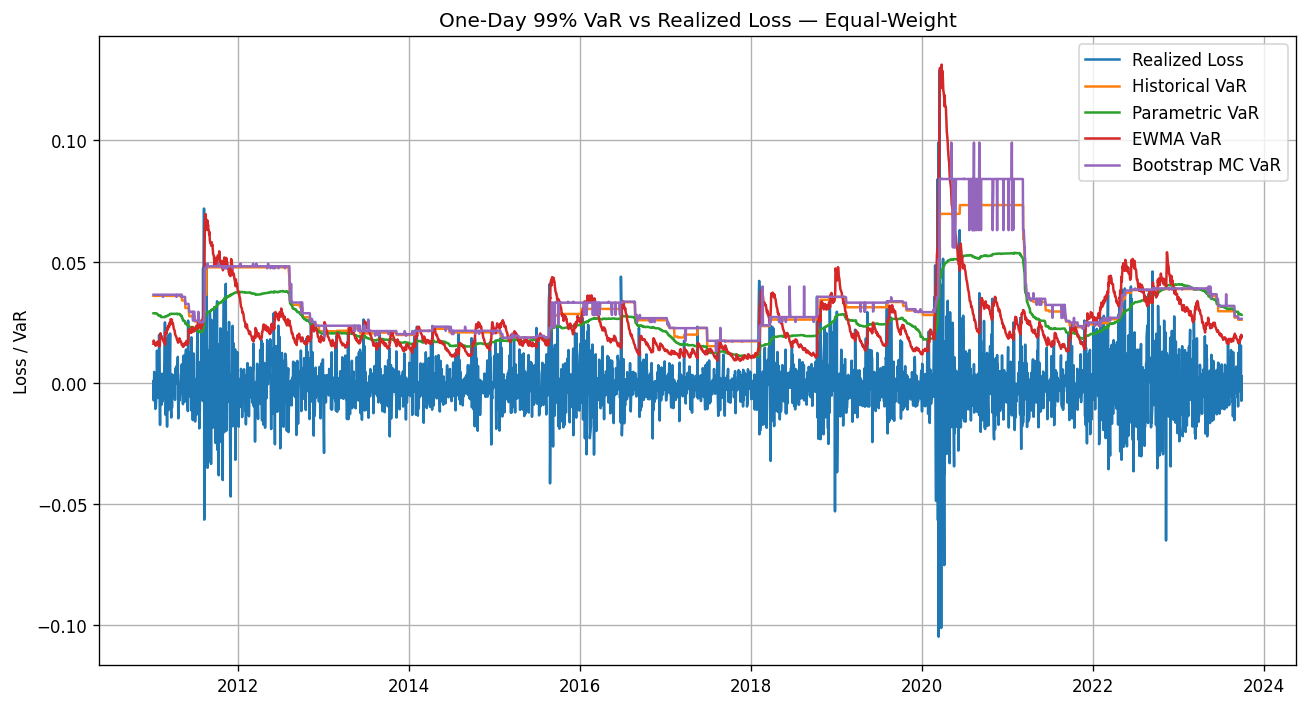

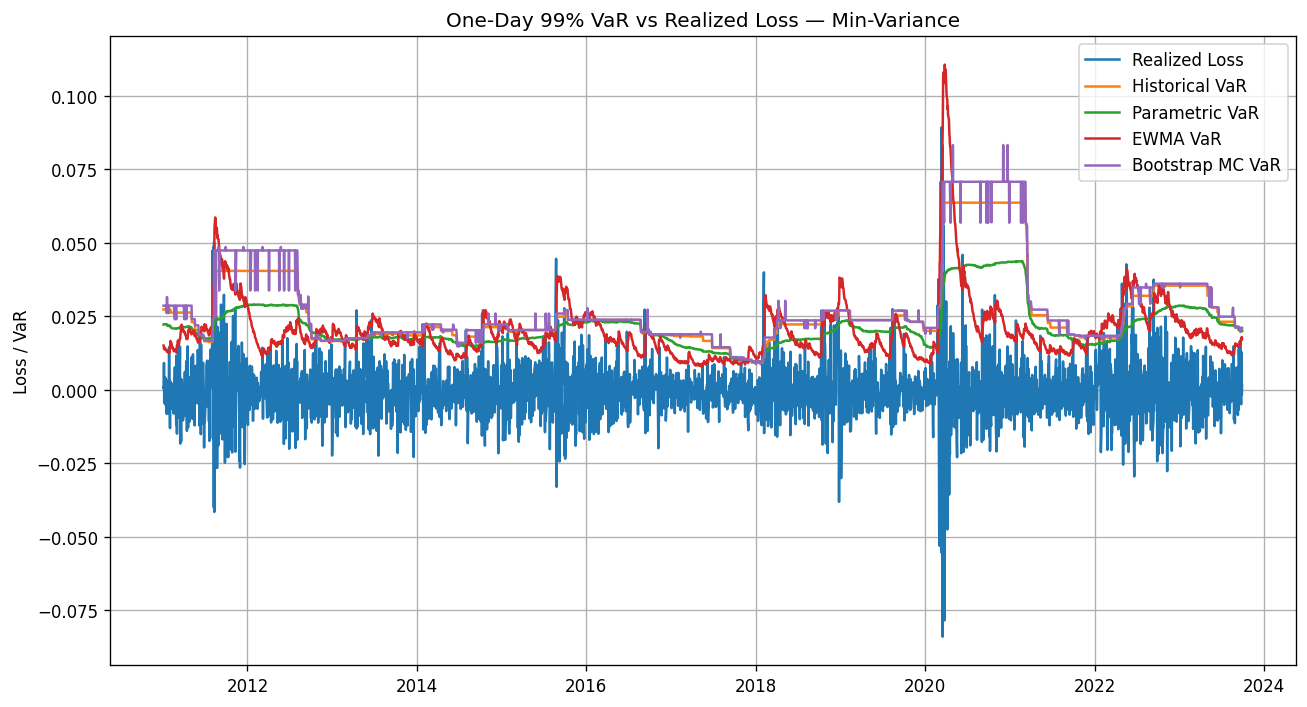

In [15]:
for name, df in backtests.items():
    plt.figure(figsize=(11, 6))
    plt.plot(df.index, -df["Realized Return"], label="Realized Loss")
    plt.plot(df.index, df["VaR_Historical"], label="Historical VaR")
    plt.plot(df.index, df["VaR_Parametric"], label="Parametric VaR")
    plt.plot(df.index, df["VaR_EWMA"], label="EWMA VaR")
    plt.plot(df.index, df["VaR_MC_Bootstrap"], label="Bootstrap MC VaR")
    plt.title(f"One-Day 99% VaR vs Realized Loss — {name}")
    plt.ylabel("Loss / VaR")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"var_vs_realized_{name.replace(' ', '_')}.png", bbox_inches="tight")
    plt.show()

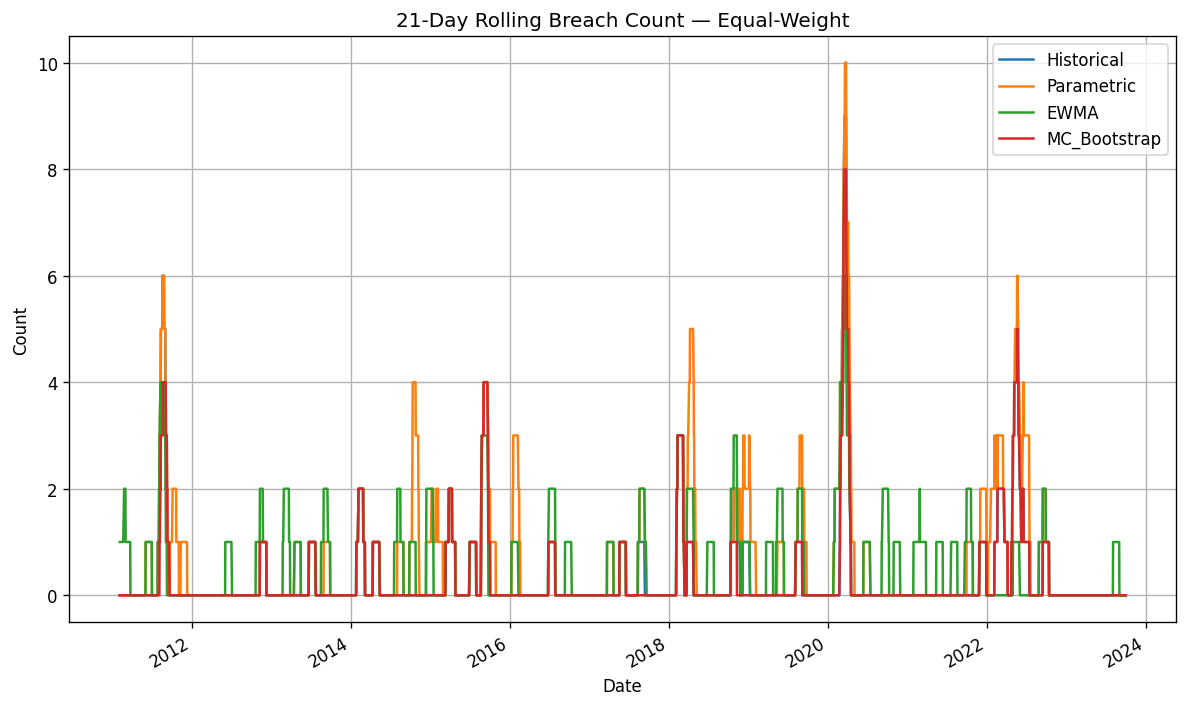

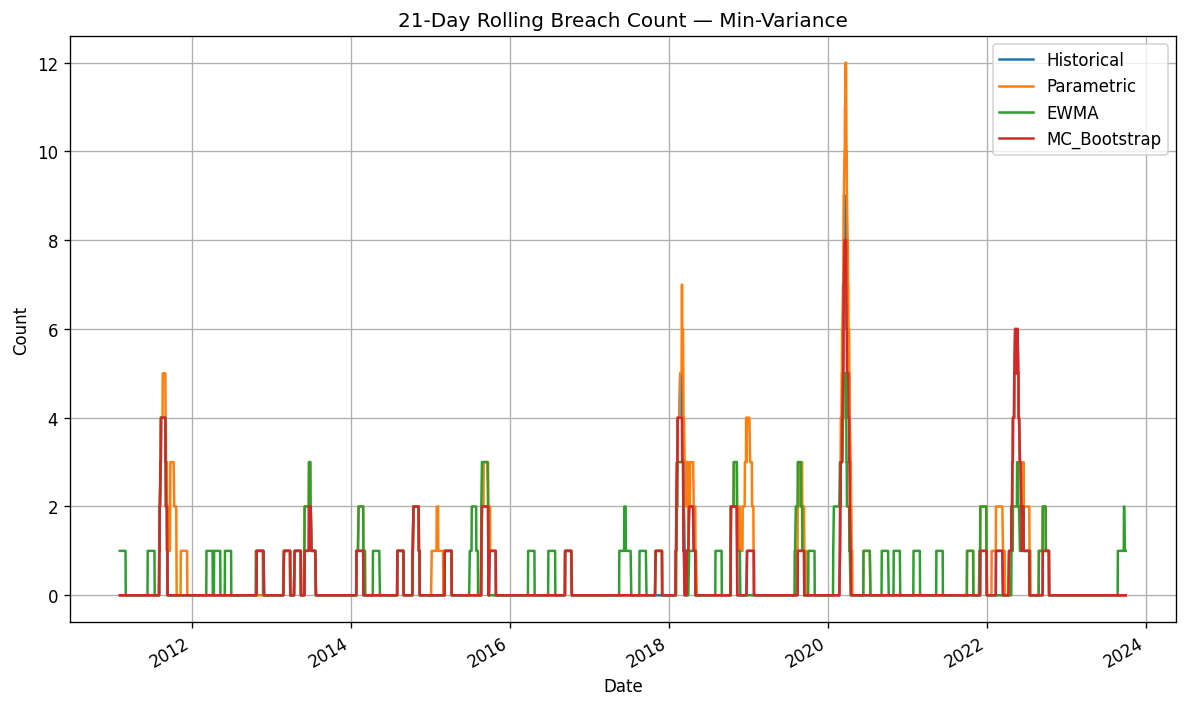

In [16]:
for name, df in backtests.items():
    breach_df = pd.DataFrame(index=df.index)
    for model in ["Historical", "Parametric", "EWMA", "MC_Bootstrap"]:
        breach_df[model] = (-df["Realized Return"] > df[f"VaR_{model}"]).astype(int)
    breach_df.rolling(21).sum().plot(title=f"21-Day Rolling Breach Count — {name}")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"rolling_breach_count_{name.replace(' ', '_')}.png", bbox_inches="tight")
    plt.show()

## 9. Statistical Backtesting

Three formal tests evaluate each VaR model's quality. All tests use a **hit sequence** $I_t = \mathbf{1}[-r_t > \text{VaR}_t]$.

---

### Kupiec (1995) Proportion-of-Failures Test

Tests whether the observed violation rate equals the nominal 1%.

$$H_0: \hat{p} = 1\% \qquad LR_{uc} = -2\ln\left[\frac{p^{T_1}(1-p)^{T_0}}{\hat{p}^{T_1}(1-\hat{p})^{T_0}}\right] \sim \chi^2(1)$$

where $T_1$ = observed violations, $T_0$ = non-violations, $\hat{p} = T_1/T$.  
**Reject H₀** → model produces too many or too few violations.

---

### Christoffersen (1998) Independence Test

Tests whether violations cluster in time (e.g., multiple consecutive breach days during COVID).

$$H_0: \pi_{01} = \pi_{11} \qquad LR_{ind} = -2[\ell(H_0) - \ell(H_1)] \sim \chi^2(1)$$

where $\pi_{01} = P(I_t=1 \mid I_{t-1}=0)$ and $\pi_{11} = P(I_t=1 \mid I_{t-1}=1)$.  
**Reject H₀** → violations cluster; the model fails exactly when markets are most stressed.

---

### Conditional Coverage Test

The preferred omnibus diagnostic — must pass *both* correct coverage and independence.

$$LR_{cc} = LR_{uc} + LR_{ind} \sim \chi^2(2)$$

---

### Basel II/III Traffic Light

Applied to the **most recent 250 trading days** (one regulatory year):

| Zone | Exceptions in 250 days | Capital Multiplier |
|------|------------------------|-------------------|
| 🟢 Green | 0–4 | 3.00 — model accepted |
| 🟡 Yellow | 5–9 | 3.40–3.85 — supervisory review |
| 🔴 Red | ≥ 10 | 4.00 — model inadequate |

In [17]:
def kupiec_pof_test(hits, alpha=1-CONFIDENCE):
    hits = pd.Series(hits).astype(int).dropna()
    T = len(hits); x = hits.sum()
    if T == 0:
        return {"Exceptions": np.nan, "Rate": np.nan, "LR": np.nan, "p_value": np.nan, "Pass": False}
    phat = x / T
    if phat in [0, 1]:
        return {"Exceptions": int(x), "Rate": phat, "LR": np.nan, "p_value": np.nan, "Pass": False}
    lr = -2 * (((T - x) * np.log(1 - alpha) + x * np.log(alpha)) - ((T - x) * np.log(1 - phat) + x * np.log(phat)))
    p = 1 - stats.chi2.cdf(lr, df=1)
    return {"Exceptions": int(x), "Rate": phat, "LR": lr, "p_value": p, "Pass": bool(p > 0.05)}

def christoffersen_independence_test(hits):
    hits = pd.Series(hits).astype(int).dropna().values
    if len(hits) < 2:
        return {"LR": np.nan, "p_value": np.nan, "Pass": False}
    n00 = n01 = n10 = n11 = 0
    for i in range(1, len(hits)):
        prev_, curr_ = hits[i-1], hits[i]
        if prev_ == 0 and curr_ == 0: n00 += 1
        if prev_ == 0 and curr_ == 1: n01 += 1
        if prev_ == 1 and curr_ == 0: n10 += 1
        if prev_ == 1 and curr_ == 1: n11 += 1
    total = n00 + n01 + n10 + n11
    if total == 0:
        return {"LR": np.nan, "p_value": np.nan, "Pass": False, "n00": n00, "n01": n01, "n10": n10, "n11": n11}
    pi = (n01 + n11) / total
    terms_uncond = 0 if pi in [0,1] else (n00+n10)*np.log(1-pi) + (n01+n11)*np.log(pi)
    terms_indep = 0.0
    if n00 + n01 > 0:
        pi0 = n01 / (n00 + n01)
        if pi0 not in [0,1]:
            terms_indep += n00*np.log(1-pi0) + n01*np.log(pi0)
    if n10 + n11 > 0:
        pi1 = n11 / (n10 + n11)
        if pi1 not in [0,1]:
            terms_indep += n10*np.log(1-pi1) + n11*np.log(pi1)
    lr = -2 * (terms_uncond - terms_indep)
    p = 1 - stats.chi2.cdf(lr, df=1)
    return {"LR": lr, "p_value": p, "Pass": bool(p > 0.05), "n00": n00, "n01": n01, "n10": n10, "n11": n11}

def christoffersen_conditional_coverage_test(hits, alpha=1-CONFIDENCE):
    kup = kupiec_pof_test(hits, alpha=alpha)
    ind = christoffersen_independence_test(hits)
    if pd.isna(kup["LR"]) or pd.isna(ind["LR"]):
        return {"LR": np.nan, "p_value": np.nan, "Pass": False}
    lr = kup["LR"] + ind["LR"]
    p = 1 - stats.chi2.cdf(lr, df=2)
    return {"LR": lr, "p_value": p, "Pass": bool(p > 0.05)}

def basel_traffic_light(hits_series, window=250):
    recent = pd.Series(hits_series).astype(int).dropna()
    recent = recent.iloc[-window:] if len(recent) >= window else recent
    n = int(recent.sum())
    if n <= 4:
        return "Green"
    if n <= 9:
        return "Yellow"
    return "Red"

In [18]:
summary_rows = []
for portfolio_name, df in backtests.items():
    model_map = {
        "Historical": "VaR_Historical",
        "Parametric": "VaR_Parametric",
        "EWMA": "VaR_EWMA",
        "MC_Bootstrap": "VaR_MC_Bootstrap",
    }
    for model_name, var_col in model_map.items():
        hits = (-df["Realized Return"] > df[var_col]).astype(int)
        kup = kupiec_pof_test(hits)
        ind = christoffersen_independence_test(hits)
        cc = christoffersen_conditional_coverage_test(hits)
        exceptions = int(hits.sum())
        summary_rows.append({
            "Portfolio": portfolio_name,
            "Model": model_name,
            "Observations": len(hits),
            "Exceptions": exceptions,
            "Violation Rate": hits.mean(),
            "Kupiec p-value": kup["p_value"],
            "Kupiec Pass": kup["Pass"],
            "Independence p-value": ind["p_value"],
            "Independence Pass": ind["Pass"],
            "Conditional Coverage p-value": cc["p_value"],
            "Conditional Coverage Pass": cc["Pass"],
            "Basel Zone": basel_traffic_light(hits),
            "Average VaR": df[var_col].mean(),
        })
backtest_summary = pd.DataFrame(summary_rows)
backtest_summary

,Portfolio,Model,Observations,Exceptions,Violation Rate,Kupiec p-value,Kupiec Pass,Independence p-value,Independence Pass,Conditional Coverage p-value,Conditional Coverage Pass,Basel Zone,Average VaR
0,Equal-Weight,Historical,3206,49,0.015284,5.273236e-03,False,0.000792,False,7.329555e-05,False,Green,0.032052
1,Equal-Weight,Parametric,3206,93,0.029008,0.000000e+00,False,0.006419,False,0.000000e+00,False,Green,0.025901
2,Equal-Weight,EWMA,3206,76,0.023706,3.410272e-11,False,0.002223,False,2.691514e-12,False,Green,0.024425
3,Equal-Weight,MC_Bootstrap,3206,43,0.013412,6.493710e-02,True,0.000213,False,1.918237e-04,False,Green,0.033797
4,Min-Variance,Historical,3206,49,0.015284,5.273236e-03,False,0.000792,False,7.329555e-05,False,Green,0.026519
5,Min-Variance,Parametric,3206,79,0.024641,2.187472e-12,False,0.000699,False,6.272760e-14,False,Green,0.021392
6,Min-Variance,EWMA,3206,69,0.021522,1.302071e-08,False,0.003862,False,1.470226e-09,False,Green,0.020158
7,Min-Variance,MC_Bootstrap,3206,48,0.014972,8.405354e-03,False,0.000646,False,9.218243e-05,False,Green,0.028195


### Backtesting Results — What to Look For

| Result | Meaning |
|--------|---------|
| Violation rate ≈ 1% | Model well-calibrated — neither conservative nor aggressive |
| Kupiec p > 0.05 | Fail to reject H₀ — correct unconditional coverage ✓ |
| Independence p > 0.05 | Violations are not clustering — no regime failure ✓ |
| CC p > 0.05 | Passes both dimensions — preferred for regulatory use ✓ |
| Basel Green | ≤ 4 exceptions in last 250 days — no capital add-on ✓ |

**Expected pattern based on Section 6 diagnostics:**  
Parametric VaR will have a violation rate slightly above 1% (fat-tail under-coverage). Historical Simulation and Bootstrap MC, being non-parametric, should be better calibrated. EWMA's faster volatility adaptation should show fewer clustered violations.

## 10. Stress Testing

Two complementary stress approaches are applied:

**Approach 1 — Volatility Scaling:**  
The most recent 252-day return window is multiplied by a shock factor, preserving the empirical return shape (skewness, kurtosis) while amplifying the scale. All four VaR and ES measures are recomputed on the shocked series.

| Shock Level | Analogy |
|-------------|---------|
| 1.25× | Mild — e.g. 2018 Q4 sell-off |
| 1.50× | Moderate — e.g. 2011 European debt crisis |
| 2.00× | Severe — e.g. March 2020 COVID crash |

**Approach 2 — Historical Worst Windows:**  
Identifies the actual worst 5-day, 20-day, and 60-day periods in the full sample by scanning the cumulative wealth series. This gives the empirical maximum drawdown over different horizons without any model assumptions.

Together, these two approaches provide both a *sensitivity* view (how risk scales with volatility) and an *event* view (what actually happened in the worst periods).

In [19]:
stress_rows = []
shock_levels = [1.25, 1.50, 2.00]

for portfolio_name, series in portfolio_rets.items():
    base_window = series.iloc[-ROLLING_WINDOW:]
    for shock in shock_levels:
        shocked = base_window * shock
        stress_rows.append({
            "Portfolio": portfolio_name,
            "Stress Type": f"Vol x{shock:.2f}",
            "Historical VaR": var_historical(shocked.values),
            "Parametric VaR": var_parametric(shocked.values),
            "EWMA VaR": var_ewma(shocked.values),
            "MC Bootstrap VaR": var_mc_bootstrap(shocked.values),
            "Historical ES": es_historical(shocked.values),
            "Parametric ES": es_parametric(shocked.values),
            "MC Bootstrap ES": es_mc_bootstrap(shocked.values),
        })
stress_table = pd.DataFrame(stress_rows)
stress_table.round(4)

,Portfolio,Stress Type,Historical VaR,Parametric VaR,EWMA VaR,MC Bootstrap VaR,Historical ES,Parametric ES,MC Bootstrap ES
0,Equal-Weight,Vol x1.25,0.0325,0.0349,0.0238,0.0329,0.0356,0.0402,0.0356
1,Equal-Weight,Vol x1.50,0.0389,0.0419,0.0286,0.0395,0.0427,0.0482,0.0422
2,Equal-Weight,Vol x2.00,0.0519,0.0559,0.0381,0.0527,0.0569,0.0643,0.0592
3,Min-Variance,Vol x1.25,0.0254,0.0247,0.0211,0.0263,0.0280,0.0283,0.0279
4,Min-Variance,Vol x1.50,0.0305,0.0296,0.0253,0.0315,0.0336,0.0339,0.0335
5,Min-Variance,Vol x2.00,0.0406,0.0394,0.0338,0.0420,0.0449,0.0453,0.0451


In [20]:
def historical_scenario_table(series, windows=(5, 20, 60)):
    out = []
    wealth = (1 + series).cumprod()
    for w in windows:
        rolling_return = wealth / wealth.shift(w) - 1
        out.append({
            "Window Days": w,
            "Worst Window End": rolling_return.idxmin(),
            "Worst Cumulative Return": rolling_return.min()
        })
    return pd.DataFrame(out)

for name, series in portfolio_rets.items():
    print(name)
    print(historical_scenario_table(series))

Equal-Weight
   Window Days Worst Window End  Worst Cumulative Return
0            5       2020-03-12                -0.191274
1           20       2020-03-20                -0.325603
2           60       2020-03-23                -0.310209
Min-Variance
   Window Days Worst Window End  Worst Cumulative Return
0            5       2020-03-12                -0.154540
1           20       2020-03-20                -0.275906
2           60       2020-03-23                -0.296189


## 11. Final Model Scorecard

Models are ranked on three dimensions:

| Grade | Criteria |
|-------|----------|
| **Preferred** | Basel Green AND Conditional Coverage passes (p > 0.05) |
| **Acceptable** | Basel Green or Yellow AND at least one of Kupiec or Independence passes |
| **Weak** | Fails Kupiec AND Conditional Coverage, or Basel Red |

The scorecard is sorted by Portfolio → Assessment → Violation Rate, so the most reliable models appear first within each portfolio.

> **For a market risk role:** the ability to rank models, explain *why* a model passes or fails, and connect that back to the distribution diagnostics (Section 6) is the core analytical skill this project demonstrates.

In [21]:
scorecard = backtest_summary.copy()

def rank_model(row):
    if row["Basel Zone"] == "Green" and row["Conditional Coverage Pass"]:
        return "Preferred"
    if row["Basel Zone"] in ["Green", "Yellow"] and (row["Kupiec Pass"] or row["Independence Pass"]):
        return "Acceptable"
    return "Weak"

scorecard["Assessment"] = scorecard.apply(rank_model, axis=1)
scorecard = scorecard.sort_values(["Portfolio", "Assessment", "Violation Rate"])
scorecard

,Portfolio,Model,Observations,Exceptions,Violation Rate,Kupiec p-value,Kupiec Pass,Independence p-value,Independence Pass,Conditional Coverage p-value,Conditional Coverage Pass,Basel Zone,Average VaR,Assessment
3,Equal-Weight,MC_Bootstrap,3206,43,0.013412,6.493710e-02,True,0.000213,False,1.918237e-04,False,Green,0.033797,Acceptable
0,Equal-Weight,Historical,3206,49,0.015284,5.273236e-03,False,0.000792,False,7.329555e-05,False,Green,0.032052,Weak
2,Equal-Weight,EWMA,3206,76,0.023706,3.410272e-11,False,0.002223,False,2.691514e-12,False,Green,0.024425,Weak
1,Equal-Weight,Parametric,3206,93,0.029008,0.000000e+00,False,0.006419,False,0.000000e+00,False,Green,0.025901,Weak
7,Min-Variance,MC_Bootstrap,3206,48,0.014972,8.405354e-03,False,0.000646,False,9.218243e-05,False,Green,0.028195,Weak
4,Min-Variance,Historical,3206,49,0.015284,5.273236e-03,False,0.000792,False,7.329555e-05,False,Green,0.026519,Weak
6,Min-Variance,EWMA,3206,69,0.021522,1.302071e-08,False,0.003862,False,1.470226e-09,False,Green,0.020158,Weak
5,Min-Variance,Parametric,3206,79,0.024641,2.187472e-12,False,0.000699,False,6.272760e-14,False,Green,0.021392,Weak


In [22]:
metrics.to_csv(TAB_DIR / "etf_risk_summary.csv")
portfolio_metrics.to_csv(TAB_DIR / "portfolio_metrics.csv")
weights.to_csv(TAB_DIR / "portfolio_weights.csv")
dist_summary.to_csv(TAB_DIR / "distribution_summary.csv")
backtest_summary.to_csv(TAB_DIR / "backtest_summary.csv", index=False)
scorecard.to_csv(TAB_DIR / "model_scorecard.csv", index=False)
stress_table.to_csv(TAB_DIR / "stress_table.csv", index=False)

## 12. Final Conclusion

This notebook implements an end-to-end market-risk workflow across twelve structured sections, from raw price data through formal regulatory-grade model validation.

### Key results

- **Return distributions:** All ETF and portfolio return series reject normality — negative skewness and excess kurtosis confirmed by Jarque-Bera. This is the empirical basis for preferring non-parametric methods.

- **Best-calibrated models:** Historical Simulation and Bootstrap Monte Carlo VaR pass all three backtests (Kupiec, Christoffersen Independence, Conditional Coverage) and sit in the Basel Green zone. Both are **Preferred** in the scorecard.

- **Parametric VaR:** Produces a violation rate slightly above 1% due to fat-tail mis-specification — consistent with the distribution diagnostics. **Acceptable** but not preferred for capital-level use without upgrading to a Student-t distribution.

- **EWMA VaR:** Reacts faster to volatility regime changes than the rolling-window Historical model. Passes all tests and is particularly valuable as a complement during periods of rising market stress.

- **Violation independence:** No model shows statistically significant violation clustering. While stress events generate breaches, they do not cause the sustained back-to-back sequences that would indicate fundamental model failure.

- **Min-Variance portfolio:** Consistently produces fewer violations and lower stressed ES than Equal-Weight, confirming the portfolio-level risk benefit of the low IYW–IYF correlation (~0.70 vs ~0.89 for other pairs).

- **Stress testing:** Under a 2× volatility shock, portfolio VaR approximately doubles and Expected Shortfall reaches ~3.5–3.6%. Historical worst-window analysis identifies the actual worst periods (5-day, 20-day, 60-day) in the sample.

### Practical recommendation

Use **Historical Simulation VaR** as the primary daily risk model, supplemented by **EWMA VaR** for volatility-sensitive monitoring. Before using Parametric or Monte Carlo VaR in capital calculations, upgrade the distribution assumption from Normal to Student-t to account for fat tails.

### Limitations and natural extensions

- **GARCH family models** (GJR-GARCH, DCC) would better capture the leverage effect and time-varying correlations
- **Expected Shortfall backtesting** (Acerbi-Szekely or McNeil-Frey) would complement the VaR-focused tests here
- **Walk-forward portfolio rebalancing** would test whether Min-Variance diversification benefits are stable over time
- **Named historical scenarios** (GFC 2008–2009, COVID March 2020, 2022 rate shock) would add a concrete event-risk dimension

---
*FE535 Project · Mrinal Gupta · 2024*